In [1]:
!pip install yfinance ta-lib matplotlib pandas numpy seaborn

In [2]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 폰트 경로 지정 (Windows 기준, 나눔고딕 예시)
font_path = "C:/Windows/Fonts/malgun.ttf"  # '맑은 고딕' 사용
font_prop = fm.FontProperties(fname=font_path)

plt.rc("font", family=font_prop.get_name())  # Matplotlib 기본 폰트 설정

In [3]:
import yfinance as yf
import talib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def get_stock_data(ticker="AAPL", period="6mo", interval="1d"):
    stock = yf.Ticker(ticker)
    df = stock.history(period=period, interval=interval)
    df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
    df.dropna(inplace=True)
    return df

In [4]:
def evaluate_indicator(value, thresholds):
    if value >= thresholds['over3']:
        return "고평가 3단계"
    elif value >= thresholds['over2']:
        return "고평가 2단계"
    elif value >= thresholds['over1']:
        return "고평가 1단계"
    elif value <= thresholds['under3']:
        return "저평가 3단계"
    elif value <= thresholds['under2']:
        return "저평가 2단계"
    elif value <= thresholds['under1']:
        return "저평가 1단계"
    else:
        return "중립"

In [5]:
def compute_indicators(df):
    indicators = {}
    close = df['Close']
    high = df['High']
    low = df['Low']
    volume = df['Volume']

    # 볼린저 밴드
    upper, middle, lower = talib.BBANDS(close, timeperiod=20)
    indicators['Bollinger'] = {'upper': upper, 'middle': middle, 'lower': lower, 'eval': evaluate_indicator(close.iloc[-1], {
        'over3': upper.iloc[-1]*1.01,
        'over2': upper.iloc[-1],
        'over1': middle.iloc[-1]*1.05,
        'under3': lower.iloc[-1]*0.99,
        'under2': lower.iloc[-1],
        'under1': middle.iloc[-1]*0.95
    })}

    # MACD
    macd, signal, hist = talib.MACD(close)
    indicators['MACD'] = {'macd': macd, 'signal': signal, 'hist': hist, 'eval': evaluate_indicator(hist.iloc[-1], {
        'over3': 2.0, 'over2': 1.0, 'over1': 0.5,
        'under3': -2.0, 'under2': -1.0, 'under1': -0.5
    })}

    # SMA
    sma20 = talib.SMA(close, timeperiod=20)
    sma50 = talib.SMA(close, timeperiod=50)
    indicators['SMA'] = {'sma20': sma20, 'sma50': sma50, 'eval': evaluate_indicator(sma20.iloc[-1] - sma50.iloc[-1], {
        'over3': 15, 'over2': 10, 'over1': 5,
        'under3': -15, 'under2': -10, 'under1': -5
    })}

    # RSI
    rsi = talib.RSI(close)
    indicators['RSI'] = {'rsi': rsi, 'eval': evaluate_indicator(rsi.iloc[-1], {
        'over3': 85, 'over2': 75, 'over1': 70,
        'under3': 15, 'under2': 25, 'under1': 30
    })}

    # ADX
    adx = talib.ADX(high, low, close)
    indicators['ADX'] = {'adx': adx, 'eval': evaluate_indicator(adx.iloc[-1], {
        'over3': 50, 'over2': 40, 'over1': 30,
        'under3': 10, 'under2': 15, 'under1': 20
    })}

    # ATR
    atr = talib.ATR(high, low, close)
    indicators['ATR'] = {'atr': atr, 'eval': evaluate_indicator(atr.iloc[-1], {
        'over3': atr.mean() * 2.0,
        'over2': atr.mean() * 1.5,
        'over1': atr.mean() * 1.2,
        'under3': atr.mean() * 0.3,
        'under2': atr.mean() * 0.5,
        'under1': atr.mean() * 0.8
    })}

    # Stochastic
    slowk, slowd = talib.STOCH(high, low, close)
    indicators['Stochastic'] = {'slowk': slowk, 'slowd': slowd, 'eval': evaluate_indicator(slowk.iloc[-1], {
        'over3': 95, 'over2': 90, 'over1': 80,
        'under3': 5, 'under2': 10, 'under1': 20
    })}

    # CCI
    cci = talib.CCI(high, low, close)
    indicators['CCI'] = {'cci': cci, 'eval': evaluate_indicator(cci.iloc[-1], {
        'over3': 300, 'over2': 200, 'over1': 100,
        'under3': -300, 'under2': -200, 'under1': -100
    })}

    # MFI
    mfi = talib.MFI(high, low, close, volume)
    indicators['MFI'] = {'mfi': mfi, 'eval': evaluate_indicator(mfi.iloc[-1], {
        'over3': 90, 'over2': 80, 'over1': 75,
        'under3': 10, 'under2': 20, 'under1': 25
    })}

    # ROC
    roc = talib.ROC(close)
    indicators['ROC'] = {'roc': roc, 'eval': evaluate_indicator(roc.iloc[-1], {
        'over3': 30, 'over2': 20, 'over1': 10,
        'under3': -30, 'under2': -20, 'under1': -10
    })}

    # VWAP
    vwap = (close * volume).cumsum() / volume.cumsum()
    indicators['VWAP'] = {'vwap': vwap, 'eval': evaluate_indicator(close.iloc[-1] - vwap.iloc[-1], {
        'over3': 15, 'over2': 10, 'over1': 5,
        'under3': -15, 'under2': -10, 'under1': -5
    })}

    # 피보나치 되돌림
    max_price = close.max()
    min_price = close.min()
    diff = max_price - min_price
    retracement_levels = {
        '0.0%': max_price,
        '23.6%': max_price - 0.236 * diff,
        '38.2%': max_price - 0.382 * diff,
        '50.0%': max_price - 0.5 * diff,
        '61.8%': max_price - 0.618 * diff,
        '100.0%': min_price
    }
    current_price = close.iloc[-1]
    indicators['Fibonacci'] = {'levels': retracement_levels, 'eval': evaluate_indicator(current_price - retracement_levels['50.0%'], {
        'over3': diff * 0.4, 'over2': diff * 0.3, 'over1': diff * 0.2,
        'under3': -diff * 0.4, 'under2': -diff * 0.3, 'under1': -diff * 0.2
    })}

    return indicators, df

In [6]:
def plot_indicators(indicators, df):
    close = df['Close']
    date_index = df.index
    fig, axs = plt.subplots(nrows=12, ncols=1, figsize=(18, 48), sharex=True)

    titles = [
        "1. Bollinger Bands", "2. MACD", "3. SMA (20/50)", "4. RSI", "5. ADX", "6. ATR",
        "7. Stochastic Oscillator", "8. CCI", "9. MFI", "10. ROC", "11. VWAP", "12. Fibonacci Retracement"
    ]

    # 1
    axs[0].plot(date_index, close, label="종가")
    axs[0].plot(date_index, indicators['Bollinger']['upper'], label="Upper")
    axs[0].plot(date_index, indicators['Bollinger']['middle'], label="Middle")
    axs[0].plot(date_index, indicators['Bollinger']['lower'], label="Lower")
    axs[0].set_title(f"{titles[0]} (평가: {indicators['Bollinger']['eval']})")
    axs[0].legend()

    # 2
    axs[1].plot(date_index, indicators['MACD']['macd'], label="MACD")
    axs[1].plot(date_index, indicators['MACD']['signal'], label="Signal")
    axs[1].bar(date_index, indicators['MACD']['hist'], alpha=0.3, label="Hist")
    axs[1].set_title(f"{titles[1]} (평가: {indicators['MACD']['eval']})")
    axs[1].legend()

    # 3
    axs[2].plot(date_index, close, label="종가")
    axs[2].plot(date_index, indicators['SMA']['sma20'], label="SMA20")
    axs[2].plot(date_index, indicators['SMA']['sma50'], label="SMA50")
    axs[2].set_title(f"{titles[2]} (평가: {indicators['SMA']['eval']})")
    axs[2].legend()

    # 4
    axs[3].plot(date_index, indicators['RSI']['rsi'], label="RSI")
    axs[3].axhline(70, linestyle="--", color="red")
    axs[3].axhline(30, linestyle="--", color="green")
    axs[3].set_title(f"{titles[3]} (평가: {indicators['RSI']['eval']})")
    axs[3].legend()

    # 5
    axs[4].plot(date_index, indicators['ADX']['adx'], label="ADX", color="orange")
    axs[4].set_title(f"{titles[4]} (평가: {indicators['ADX']['eval']})")
    axs[4].legend()

    # 6
    axs[5].plot(date_index, indicators['ATR']['atr'], label="ATR", color="purple")
    axs[5].set_title(f"{titles[5]} (평가: {indicators['ATR']['eval']})")
    axs[5].legend()

    # 7
    axs[6].plot(date_index, indicators['Stochastic']['slowk'], label="SlowK")
    axs[6].plot(date_index, indicators['Stochastic']['slowd'], label="SlowD")
    axs[6].set_title(f"{titles[6]} (평가: {indicators['Stochastic']['eval']})")
    axs[6].legend()

    # 8
    axs[7].plot(date_index, indicators['CCI']['cci'], label="CCI", color="brown")
    axs[7].axhline(100, linestyle="--", color="red")
    axs[7].axhline(-100, linestyle="--", color="green")
    axs[7].set_title(f"{titles[7]} (평가: {indicators['CCI']['eval']})")
    axs[7].legend()

    # 9
    axs[8].plot(date_index, indicators['MFI']['mfi'], label="MFI", color="darkgreen")
    axs[8].axhline(80, linestyle="--", color="red")
    axs[8].axhline(20, linestyle="--", color="green")
    axs[8].set_title(f"{titles[8]} (평가: {indicators['MFI']['eval']})")
    axs[8].legend()

    # 10
    axs[9].plot(date_index, indicators['ROC']['roc'], label="ROC", color="navy")
    axs[9].axhline(0, linestyle="--", color="black")
    axs[9].set_title(f"{titles[9]} (평가: {indicators['ROC']['eval']})")
    axs[9].legend()

    # 11
    axs[10].plot(date_index, close, label="종가")
    axs[10].plot(date_index, indicators['VWAP']['vwap'], label="VWAP", color="olive")
    axs[10].set_title(f"{titles[10]} (평가: {indicators['VWAP']['eval']})")
    axs[10].legend()

    # 12
    axs[11].plot(date_index, close, label="종가")
    for level, val in indicators['Fibonacci']['levels'].items():
        axs[11].axhline(val, linestyle="--", label=f"Level {level}")
    axs[11].set_title(f"{titles[11]} (평가: {indicators['Fibonacci']['eval']})")
    axs[11].legend()

    plt.tight_layout()
    plt

C:\Users\dmlxo\AppData\Local\Temp\ipykernel_6248\3560231656.py:89: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\dmlxo\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  func(*args, **kwargs)
C:\Users\dmlxo\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


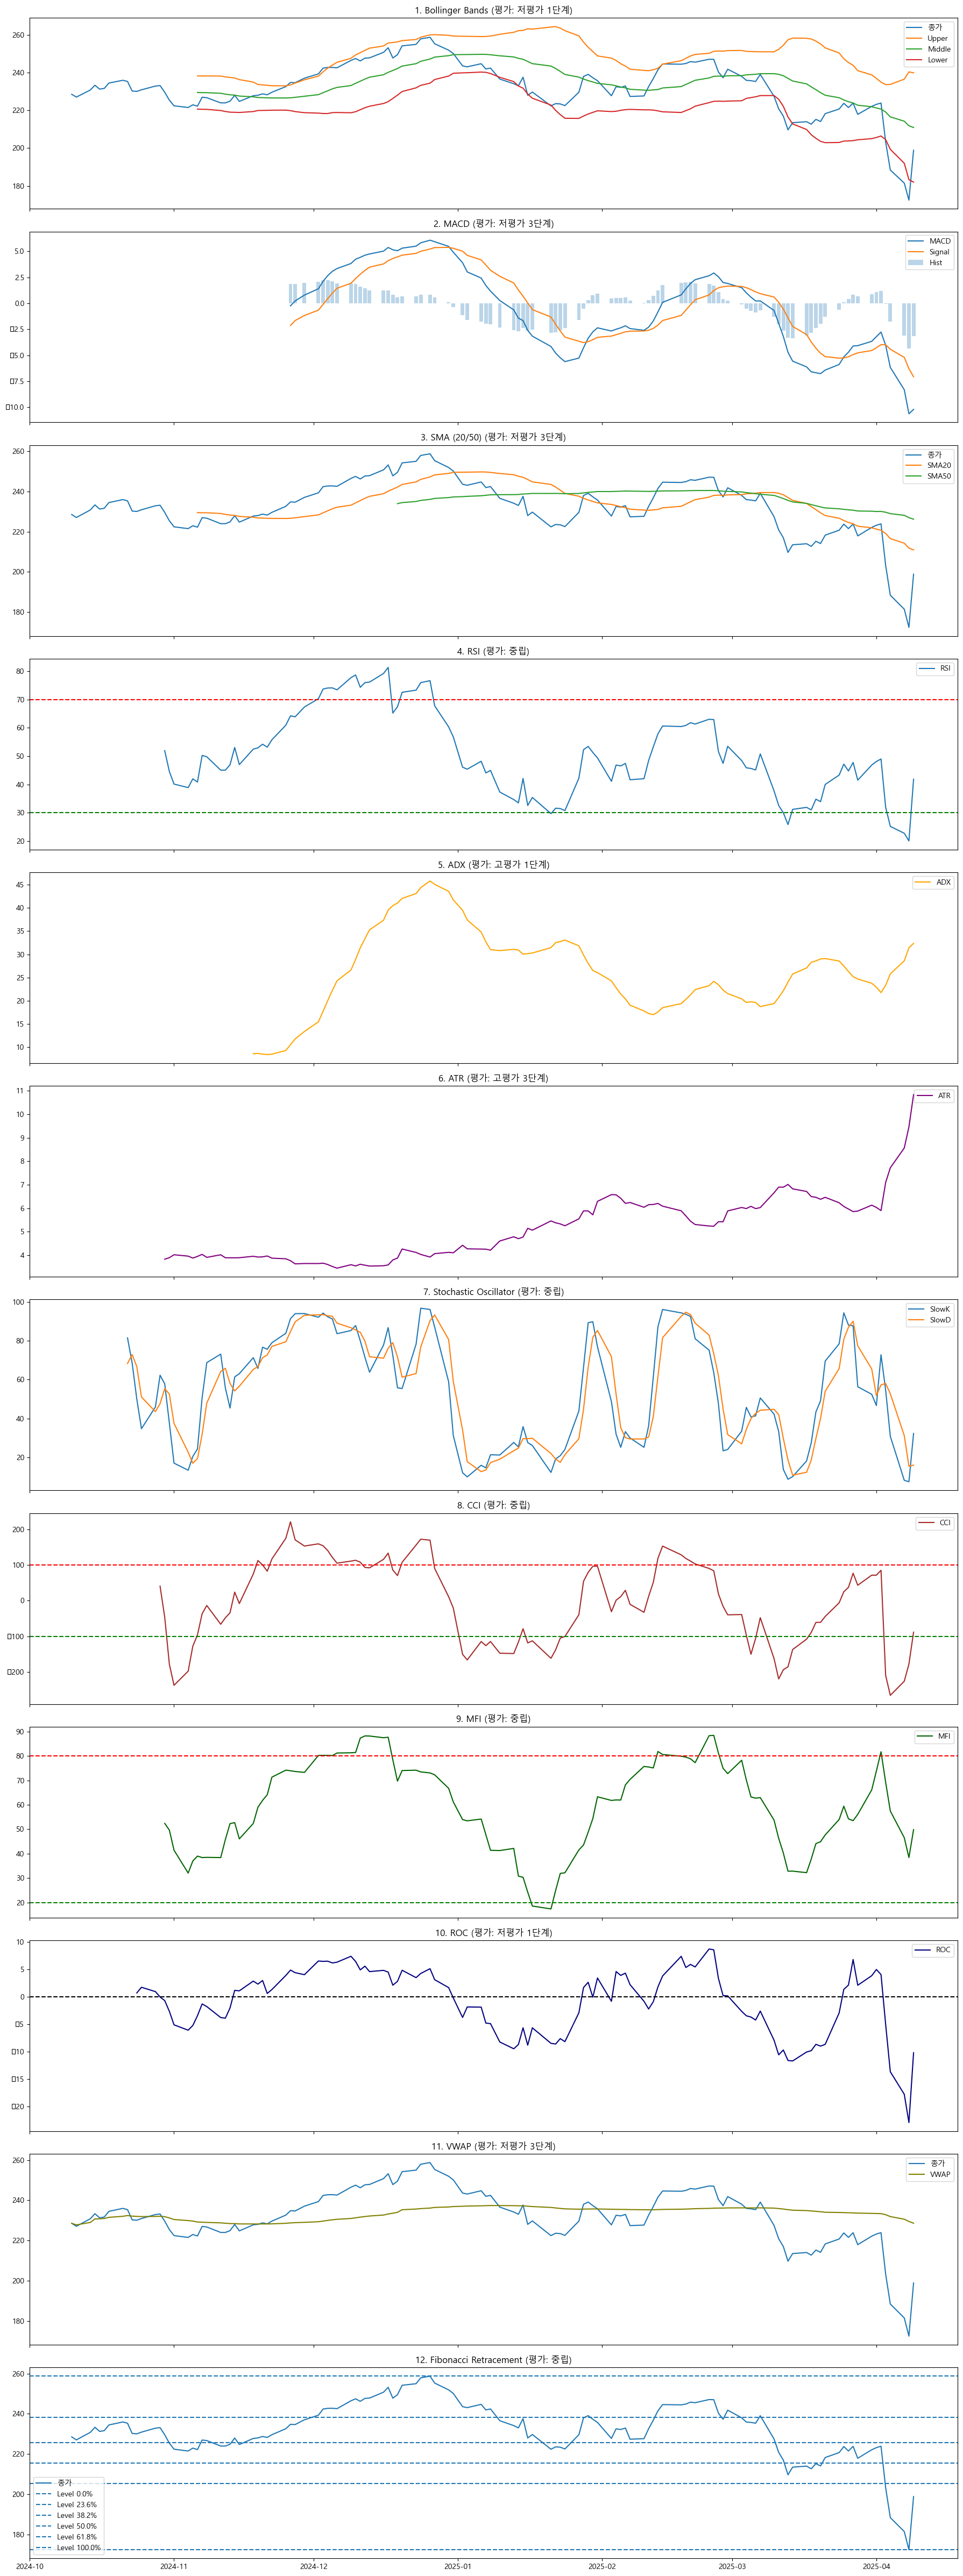

In [7]:
df = get_stock_data("AAPL")
indicators, df = compute_indicators(df)
plot_indicators(indicators, df)

In [8]:
df.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')

분석할 주식 티커를 입력하세요 (기본값: AAPL):  AAPL
데이터 기간을 입력하세요 (예: 6mo, 1y, 기본값: 6mo):  6mo
데이터 간격을 입력하세요 (예: 1d, 1h, 기본값: 1d):  1d



AAPL 기술적 지표 분석 결과:
Bollinger: 저평가 1단계
MACD: 저평가 3단계
SMA: 저평가 3단계
RSI: 중립
ADX: 고평가 1단계
ATR: 고평가 3단계
Stochastic: 중립
CCI: 중립
MFI: 중립
ROC: 저평가 1단계
VWAP: 저평가 3단계
Fibonacci: 중립


C:\Users\dmlxo\AppData\Local\Temp\ipykernel_6248\255832976.py:231: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\dmlxo\AppData\Local\Temp\ipykernel_6248\255832976.py:232: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.savefig(f"{ticker}_indicators.png")  # 그래프 저장
C:\Users\dmlxo\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


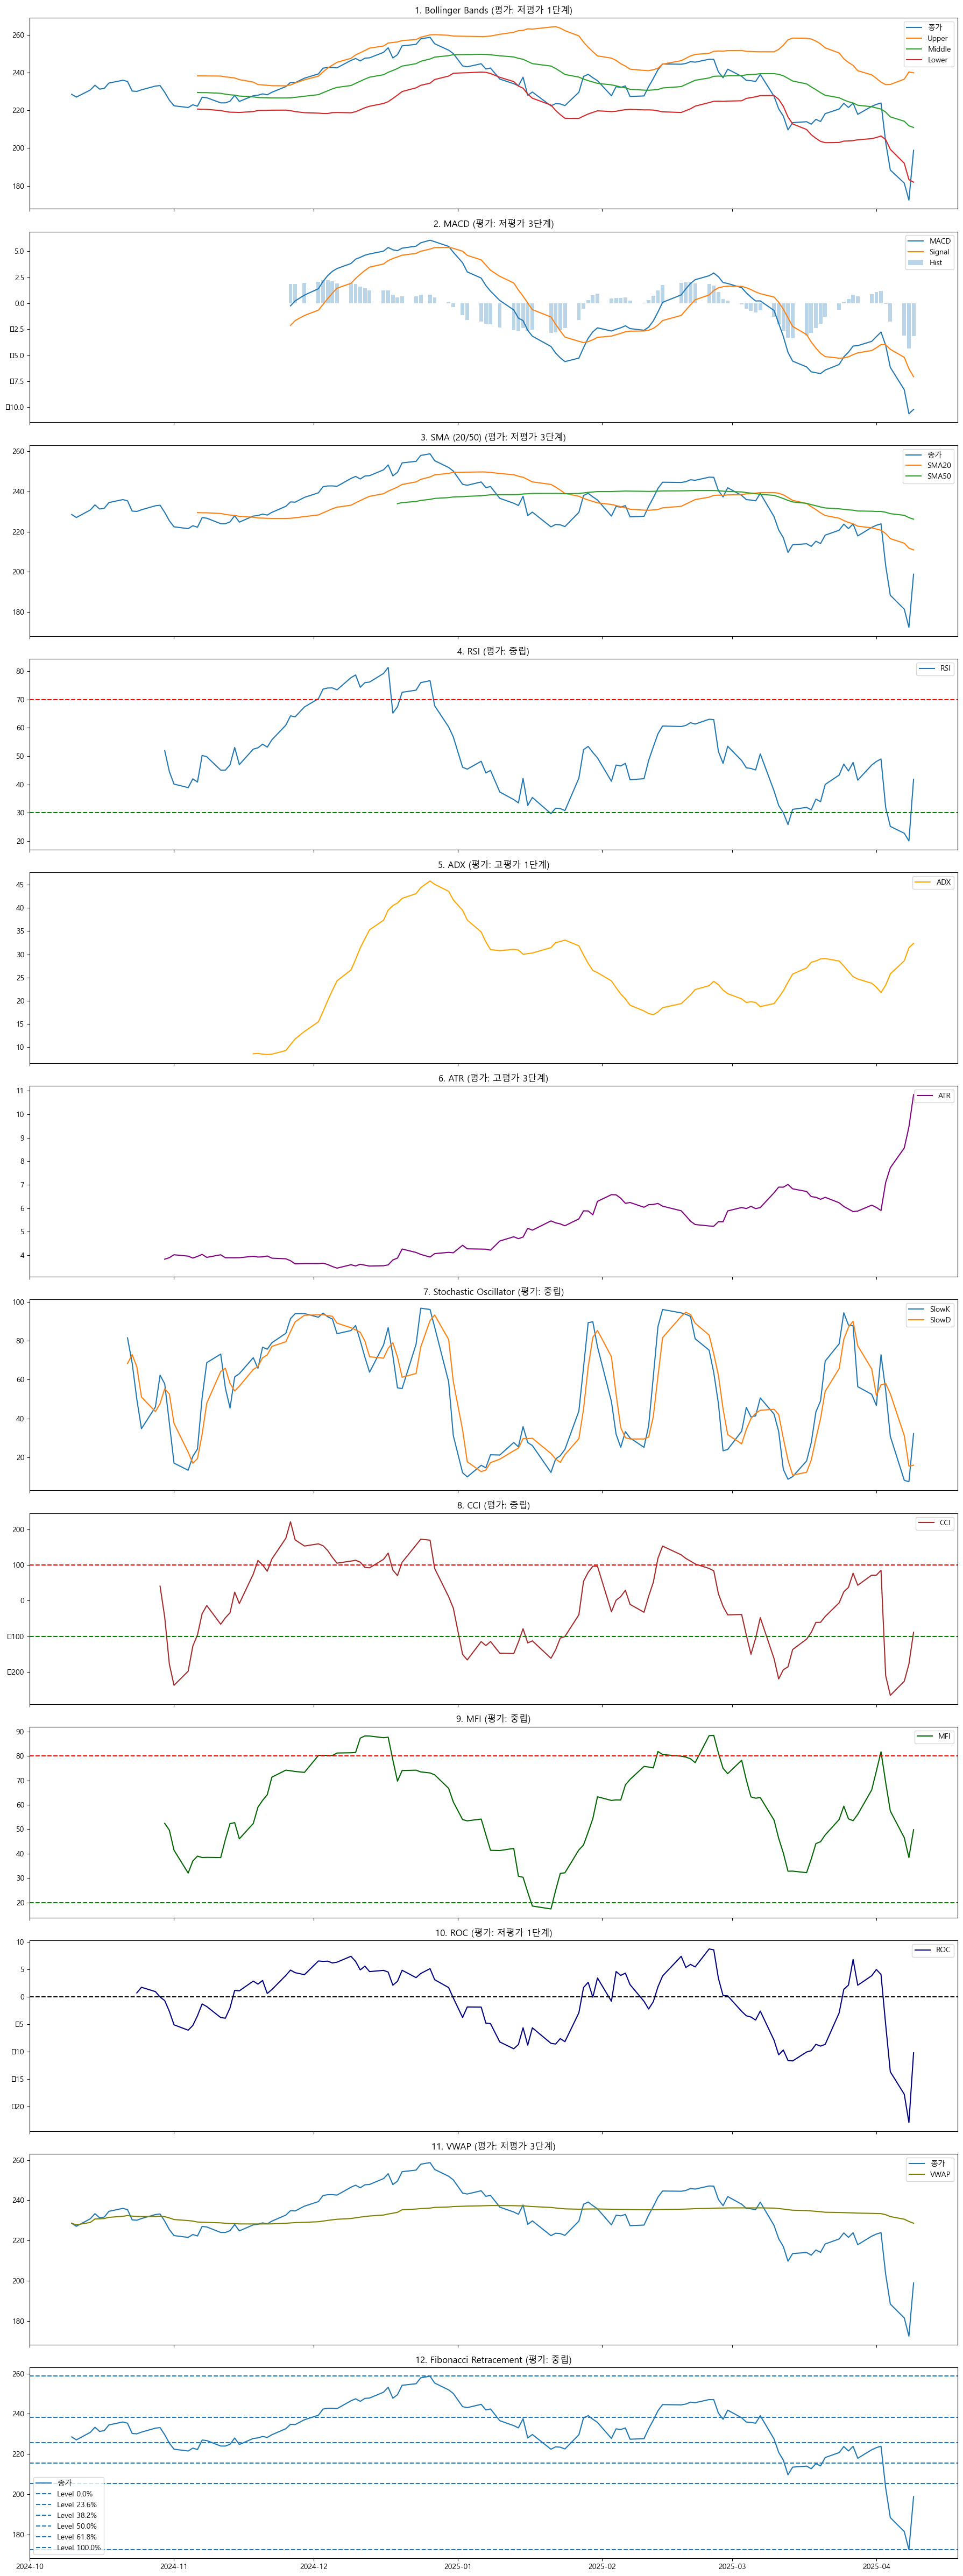

AAPL 분석 결과가 CSV 파일로 저장되었습니다.


In [10]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import yfinance as yf
import talib
import numpy as np
import pandas as pd
import os

# 폰트 설정 (Windows 기준, 맑은 고딕)
font_path = "C:/Windows/Fonts/malgun.ttf"
font_prop = fm.FontProperties(fname=font_path)
plt.rc("font", family=font_prop.get_name())

# 주식 데이터 가져오기
def get_stock_data(ticker="AAPL", period="6mo", interval="1d"):
    try:
        stock = yf.Ticker(ticker)
        df = stock.history(period=period, interval=interval)
        if df.empty:
            raise ValueError(f"{ticker}에 대한 데이터가 없습니다.")
        df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
        df.dropna(inplace=True)
        return df
    except Exception as e:
        print(f"데이터 가져오기 오류: {e}")
        return None

# 지표 평가 함수
def evaluate_indicator(value, thresholds):
    if value >= thresholds['over3']:
        return "고평가 3단계"
    elif value >= thresholds['over2']:
        return "고평가 2단계"
    elif value >= thresholds['over1']:
        return "고평가 1단계"
    elif value <= thresholds['under3']:
        return "저평가 3단계"
    elif value <= thresholds['under2']:
        return "저평가 2단계"
    elif value <= thresholds['under1']:
        return "저평가 1단계"
    else:
        return "중립"

# 기술적 지표 계산
def compute_indicators(df):
    try:
        indicators = {}
        close = df['Close']
        high = df['High']
        low = df['Low']
        volume = df['Volume']

        # 볼린저 밴드
        upper, middle, lower = talib.BBANDS(close, timeperiod=20)
        indicators['Bollinger'] = {'upper': upper, 'middle': middle, 'lower': lower, 'eval': evaluate_indicator(close.iloc[-1], {
            'over3': upper.iloc[-1]*1.01, 'over2': upper.iloc[-1], 'over1': middle.iloc[-1]*1.05,
            'under3': lower.iloc[-1]*0.99, 'under2': lower.iloc[-1], 'under1': middle.iloc[-1]*0.95
        })}

        # MACD
        macd, signal, hist = talib.MACD(close)
        indicators['MACD'] = {'macd': macd, 'signal': signal, 'hist': hist, 'eval': evaluate_indicator(hist.iloc[-1], {
            'over3': 2.0, 'over2': 1.0, 'over1': 0.5, 'under3': -2.0, 'under2': -1.0, 'under1': -0.5
        })}

        # SMA
        sma20 = talib.SMA(close, timeperiod=20)
        sma50 = talib.SMA(close, timeperiod=50)
        indicators['SMA'] = {'sma20': sma20, 'sma50': sma50, 'eval': evaluate_indicator(sma20.iloc[-1] - sma50.iloc[-1], {
            'over3': 15, 'over2': 10, 'over1': 5, 'under3': -15, 'under2': -10, 'under1': -5
        })}

        # RSI
        rsi = talib.RSI(close)
        indicators['RSI'] = {'rsi': rsi, 'eval': evaluate_indicator(rsi.iloc[-1], {
            'over3': 85, 'over2': 75, 'over1': 70, 'under3': 15, 'under2': 25, 'under1': 30
        })}

        # ADX
        adx = talib.ADX(high, low, close)
        indicators['ADX'] = {'adx': adx, 'eval': evaluate_indicator(adx.iloc[-1], {
            'over3': 50, 'over2': 40, 'over1': 30, 'under3': 10, 'under2': 15, 'under1': 20
        })}

        # ATR
        atr = talib.ATR(high, low, close)
        indicators['ATR'] = {'atr': atr, 'eval': evaluate_indicator(atr.iloc[-1], {
            'over3': atr.mean() * 2.0, 'over2': atr.mean() * 1.5, 'over1': atr.mean() * 1.2,
            'under3': atr.mean() * 0.3, 'under2': atr.mean() * 0.5, 'under1': atr.mean() * 0.8
        })}

        # Stochastic
        slowk, slowd = talib.STOCH(high, low, close)
        indicators['Stochastic'] = {'slowk': slowk, 'slowd': slowd, 'eval': evaluate_indicator(slowk.iloc[-1], {
            'over3': 95, 'over2': 90, 'over1': 80, 'under3': 5, 'under2': 10, 'under1': 20
        })}

        # CCI
        cci = talib.CCI(high, low, close)
        indicators['CCI'] = {'cci': cci, 'eval': evaluate_indicator(cci.iloc[-1], {
            'over3': 300, 'over2': 200, 'over1': 100, 'under3': -300, 'under2': -200, 'under1': -100
        })}

        # MFI
        mfi = talib.MFI(high, low, close, volume)
        indicators['MFI'] = {'mfi': mfi, 'eval': evaluate_indicator(mfi.iloc[-1], {
            'over3': 90, 'over2': 80, 'over1': 75, 'under3': 10, 'under2': 20, 'under1': 25
        })}

        # ROC
        roc = talib.ROC(close)
        indicators['ROC'] = {'roc': roc, 'eval': evaluate_indicator(roc.iloc[-1], {
            'over3': 30, 'over2': 20, 'over1': 10, 'under3': -30, 'under2': -20, 'under1': -10
        })}

        # VWAP
        vwap = (close * volume).cumsum() / volume.cumsum()
        indicators['VWAP'] = {'vwap': vwap, 'eval': evaluate_indicator(close.iloc[-1] - vwap.iloc[-1], {
            'over3': 15, 'over2': 10, 'over1': 5, 'under3': -15, 'under2': -10, 'under1': -5
        })}

        # 피보나치 되돌림
        max_price = close.max()
        min_price = close.min()
        diff = max_price - min_price
        retracement_levels = {
            '0.0%': max_price, '23.6%': max_price - 0.236 * diff, '38.2%': max_price - 0.382 * diff,
            '50.0%': max_price - 0.5 * diff, '61.8%': max_price - 0.618 * diff, '100.0%': min_price
        }
        current_price = close.iloc[-1]
        indicators['Fibonacci'] = {'levels': retracement_levels, 'eval': evaluate_indicator(current_price - retracement_levels['50.0%'], {
            'over3': diff * 0.4, 'over2': diff * 0.3, 'over1': diff * 0.2,
            'under3': -diff * 0.4, 'under2': -diff * 0.3, 'under1': -diff * 0.2
        })}

        return indicators, df
    except Exception as e:
        print(f"지표 계산 오류: {e}")
        return None, df

# 지표 시각화
def plot_indicators(indicators, df, ticker):
    close = df['Close']
    date_index = df.index
    fig, axs = plt.subplots(nrows=12, ncols=1, figsize=(18, 48), sharex=True)

    titles = [
        "1. Bollinger Bands", "2. MACD", "3. SMA (20/50)", "4. RSI", "5. ADX", "6. ATR",
        "7. Stochastic Oscillator", "8. CCI", "9. MFI", "10. ROC", "11. VWAP", "12. Fibonacci Retracement"
    ]

    # 볼린저 밴드
    axs[0].plot(date_index, close, label="종가")
    axs[0].plot(date_index, indicators['Bollinger']['upper'], label="Upper")
    axs[0].plot(date_index, indicators['Bollinger']['middle'], label="Middle")
    axs[0].plot(date_index, indicators['Bollinger']['lower'], label="Lower")
    axs[0].set_title(f"{titles[0]} (평가: {indicators['Bollinger']['eval']})")
    axs[0].legend()

    # MACD
    axs[1].plot(date_index, indicators['MACD']['macd'], label="MACD")
    axs[1].plot(date_index, indicators['MACD']['signal'], label="Signal")
    axs[1].bar(date_index, indicators['MACD']['hist'], alpha=0.3, label="Hist")
    axs[1].set_title(f"{titles[1]} (평가: {indicators['MACD']['eval']})")
    axs[1].legend()

    # SMA
    axs[2].plot(date_index, close, label="종가")
    axs[2].plot(date_index, indicators['SMA']['sma20'], label="SMA20")
    axs[2].plot(date_index, indicators['SMA']['sma50'], label="SMA50")
    axs[2].set_title(f"{titles[2]} (평가: {indicators['SMA']['eval']})")
    axs[2].legend()

    # RSI
    axs[3].plot(date_index, indicators['RSI']['rsi'], label="RSI")
    axs[3].axhline(70, linestyle="--", color="red")
    axs[3].axhline(30, linestyle="--", color="green")
    axs[3].set_title(f"{titles[3]} (평가: {indicators['RSI']['eval']})")
    axs[3].legend()

    # ADX
    axs[4].plot(date_index, indicators['ADX']['adx'], label="ADX", color="orange")
    axs[4].set_title(f"{titles[4]} (평가: {indicators['ADX']['eval']})")
    axs[4].legend()

    # ATR
    axs[5].plot(date_index, indicators['ATR']['atr'], label="ATR", color="purple")
    axs[5].set_title(f"{titles[5]} (평가: {indicators['ATR']['eval']})")
    axs[5].legend()

    # Stochastic
    axs[6].plot(date_index, indicators['Stochastic']['slowk'], label="SlowK")
    axs[6].plot(date_index, indicators['Stochastic']['slowd'], label="SlowD")
    axs[6].set_title(f"{titles[6]} (평가: {indicators['Stochastic']['eval']})")
    axs[6].legend()

    # CCI
    axs[7].plot(date_index, indicators['CCI']['cci'], label="CCI", color="brown")
    axs[7].axhline(100, linestyle="--", color="red")
    axs[7].axhline(-100, linestyle="--", color="green")
    axs[7].set_title(f"{titles[7]} (평가: {indicators['CCI']['eval']})")
    axs[7].legend()

    # MFI
    axs[8].plot(date_index, indicators['MFI']['mfi'], label="MFI", color="darkgreen")
    axs[8].axhline(80, linestyle="--", color="red")
    axs[8].axhline(20, linestyle="--", color="green")
    axs[8].set_title(f"{titles[8]} (평가: {indicators['MFI']['eval']})")
    axs[8].legend()

    # ROC
    axs[9].plot(date_index, indicators['ROC']['roc'], label="ROC", color="navy")
    axs[9].axhline(0, linestyle="--", color="black")
    axs[9].set_title(f"{titles[9]} (평가: {indicators['ROC']['eval']})")
    axs[9].legend()

    # VWAP
    axs[10].plot(date_index, close, label="종가")
    axs[10].plot(date_index, indicators['VWAP']['vwap'], label="VWAP", color="olive")
    axs[10].set_title(f"{titles[10]} (평가: {indicators['VWAP']['eval']})")
    axs[10].legend()

    # Fibonacci
    axs[11].plot(date_index, close, label="종가")
    for level, val in indicators['Fibonacci']['levels'].items():
        axs[11].axhline(val, linestyle="--", label=f"Level {level}")
    axs[11].set_title(f"{titles[11]} (평가: {indicators['Fibonacci']['eval']})")
    axs[11].legend()

    plt.tight_layout()
    plt.savefig(f"{ticker}_indicators.png")  # 그래프 저장
    plt.show()

# 요약 출력
def print_summary(indicators, ticker):
    print(f"\n{ticker} 기술적 지표 분석 결과:")
    for name, data in indicators.items():
        print(f"{name}: {data['eval']}")

# CSV로 저장
def save_to_csv(indicators, ticker):
    eval_data = {name: data['eval'] for name, data in indicators.items()}
    df_eval = pd.DataFrame([eval_data])
    df_eval.to_csv(f"{ticker}_indicators_eval.csv", index=False, encoding='utf-8-sig')
    print(f"{ticker} 분석 결과가 CSV 파일로 저장되었습니다.")

# 메인 실행 함수
def main():
    ticker = input("분석할 주식 티커를 입력하세요 (기본값: AAPL): ") or "AAPL"
    period = input("데이터 기간을 입력하세요 (예: 6mo, 1y, 기본값: 6mo): ") or "6mo"
    interval = input("데이터 간격을 입력하세요 (예: 1d, 1h, 기본값: 1d): ") or "1d"

    df = get_stock_data(ticker, period, interval)
    if df is None:
        return

    indicators, df = compute_indicators(df)
    if indicators is None:
        return

    print_summary(indicators, ticker)
    plot_indicators(indicators, df, ticker)
    save_to_csv(indicators, ticker)

if __name__ == "__main__":
    main()

분석할 주식 티커를 입력하세요 (기본값: AAPL):  AAPL
데이터 기간을 입력하세요 (예: 6mo, 1y, 기본값: 6mo):  6mo
데이터 간격을 입력하세요 (예: 1d, 1h, 기본값: 1d):  1d



AAPL 기술적 지표 분석 결과:
Bollinger: 저평가 1단계 (점수: 1)
MACD: 저평가 3단계 (점수: 3)
SMA: 저평가 3단계 (점수: 3)
RSI: 중립 (점수: 0)
ADX: 고평가 1단계 (점수: -1)
ATR: 고평가 3단계 (점수: -3)
Stochastic: 중립 (점수: 0)
CCI: 중립 (점수: 0)
MFI: 중립 (점수: 0)
ROC: 저평가 1단계 (점수: 1)
VWAP: 저평가 3단계 (점수: 3)
Fibonacci: 중립 (점수: 0)

종합 평가:
종합 점수: 0.83
다수결 신호: 저평가 경향
종합 신호: 중립


C:\Users\dmlxo\AppData\Local\Temp\ipykernel_6248\1931473366.py:228: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\dmlxo\AppData\Local\Temp\ipykernel_6248\1931473366.py:229: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.savefig(f"{ticker}_indicators.png")
C:\Users\dmlxo\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


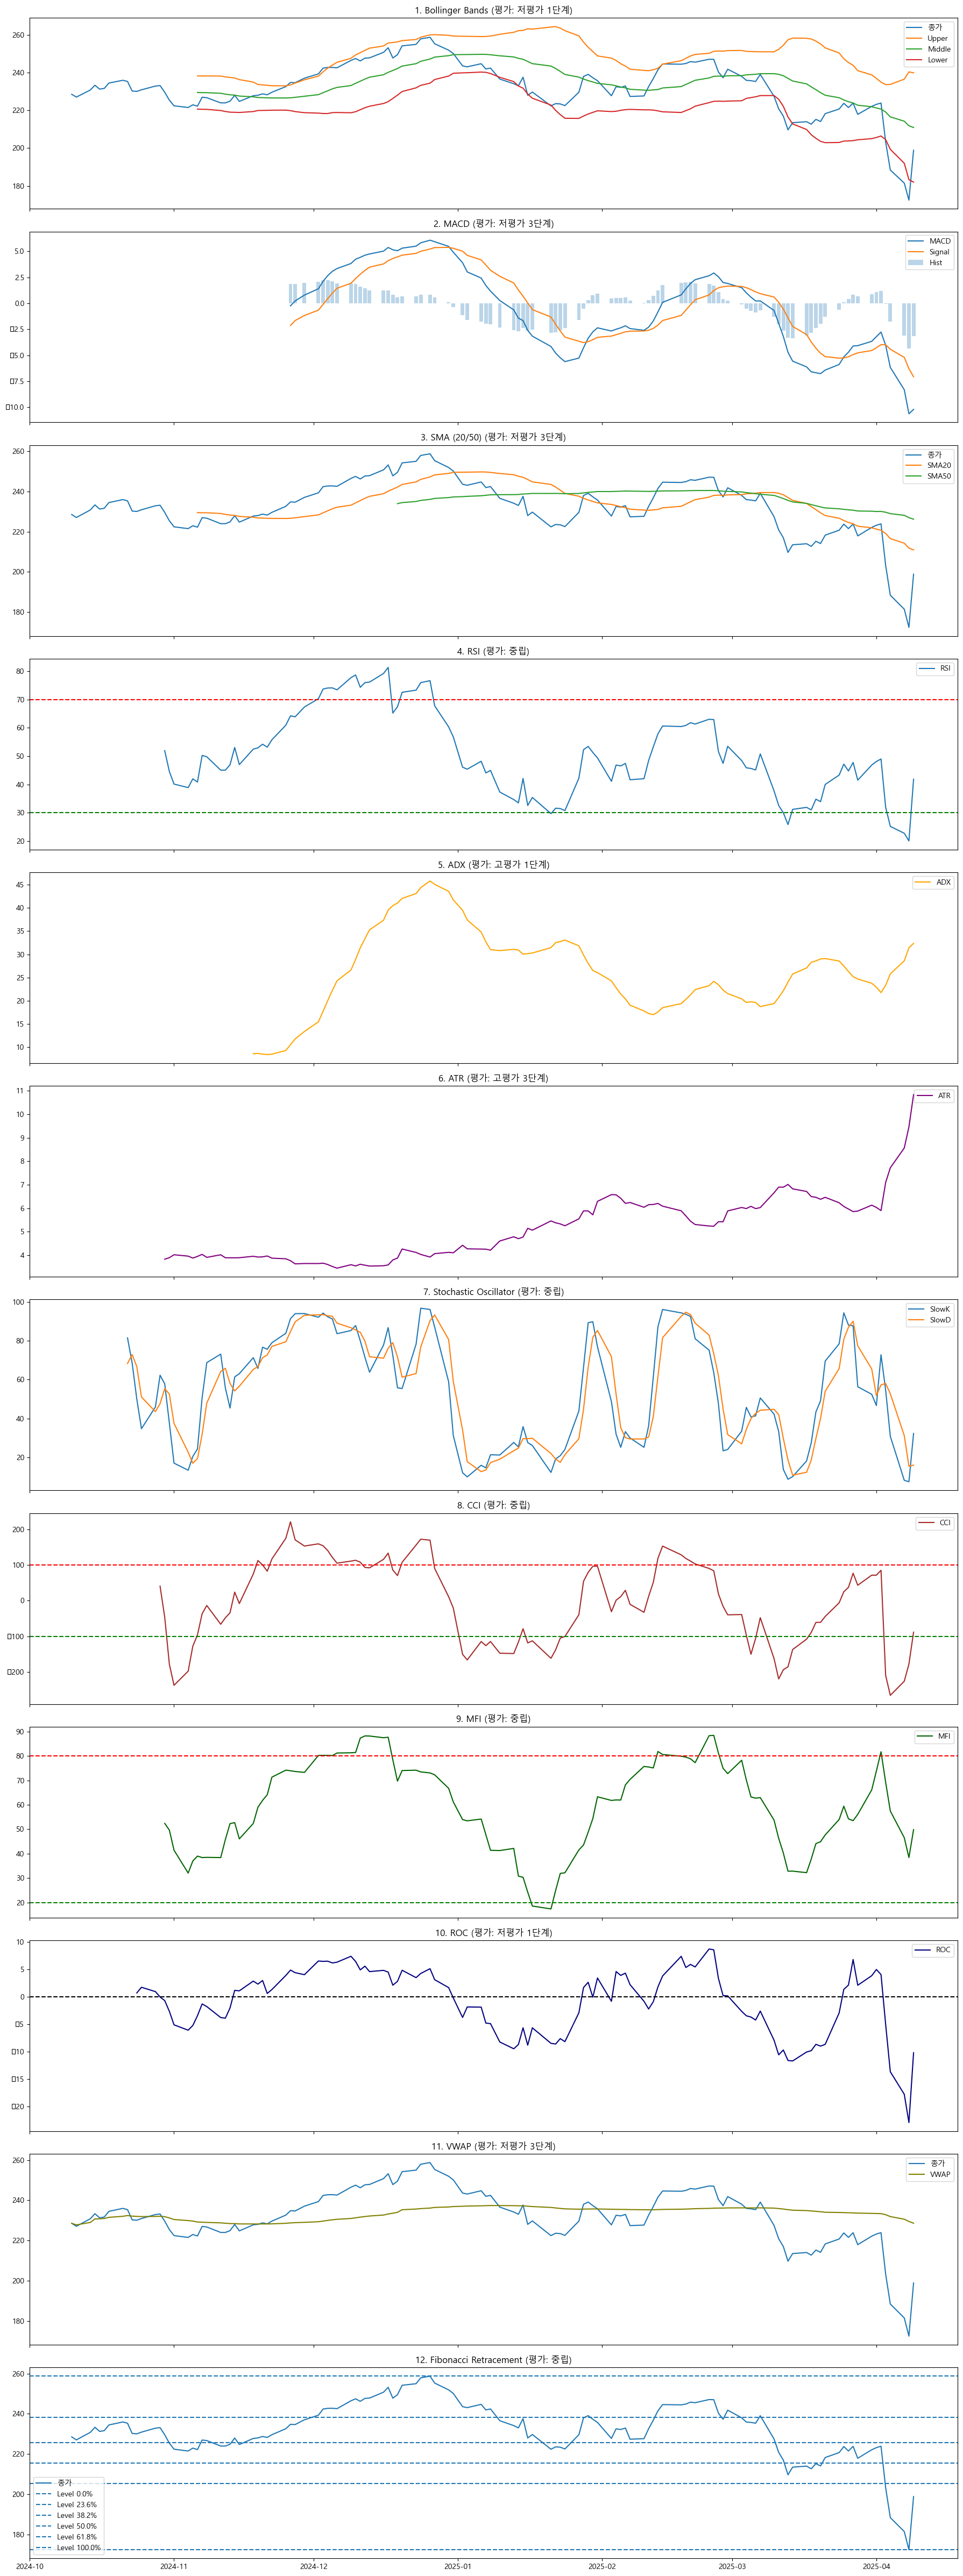

AAPL 분석 결과가 CSV 파일로 저장되었습니다.


In [12]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import yfinance as yf
import talib
import numpy as np
import pandas as pd
import os

# 폰트 설정 (Windows 기준, 맑은 고딕)
font_path = "C:/Windows/Fonts/malgun.ttf"
font_prop = fm.FontProperties(fname=font_path)
plt.rc("font", family=font_prop.get_name())

# 주식 데이터 가져오기
def get_stock_data(ticker="AAPL", period="6mo", interval="1d"):
    try:
        stock = yf.Ticker(ticker)
        df = stock.history(period=period, interval=interval)
        if df.empty:
            raise ValueError(f"{ticker}에 대한 데이터가 없습니다.")
        df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
        df.dropna(inplace=True)
        return df
    except Exception as e:
        print(f"데이터 가져오기 오류: {e}")
        return None

# 지표 평가 함수
def evaluate_indicator(value, thresholds):
    if value >= thresholds['over3']:
        return "고평가 3단계"
    elif value >= thresholds['over2']:
        return "고평가 2단계"
    elif value >= thresholds['over1']:
        return "고평가 1단계"
    elif value <= thresholds['under3']:
        return "저평가 3단계"
    elif value <= thresholds['under2']:
        return "저평가 2단계"
    elif value <= thresholds['under1']:
        return "저평가 1단계"
    else:
        return "중립"

# 평가를 수치로 변환 (새로운 매핑)
def eval_to_score(eval_str):
    eval_map = {
        "고평가 3단계": -3, "고평가 2단계": -2, "고평가 1단계": -1,
        "중립": 0,
        "저평가 1단계": 1, "저평가 2단계": 2, "저평가 3단계": 3
    }
    return eval_map.get(eval_str, 0)

# 기술적 지표 계산
def compute_indicators(df):
    try:
        indicators = {}
        close = df['Close']
        high = df['High']
        low = df['Low']
        volume = df['Volume']

        # 볼린저 밴드
        upper, middle, lower = talib.BBANDS(close, timeperiod=20)
        indicators['Bollinger'] = {'upper': upper, 'middle': middle, 'lower': lower, 'eval': evaluate_indicator(close.iloc[-1], {
            'over3': upper.iloc[-1]*1.01, 'over2': upper.iloc[-1], 'over1': middle.iloc[-1]*1.05,
            'under3': lower.iloc[-1]*0.99, 'under2': lower.iloc[-1], 'under1': middle.iloc[-1]*0.95
        })}

        # MACD
        macd, signal, hist = talib.MACD(close)
        indicators['MACD'] = {'macd': macd, 'signal': signal, 'hist': hist, 'eval': evaluate_indicator(hist.iloc[-1], {
            'over3': 2.0, 'over2': 1.0, 'over1': 0.5, 'under3': -2.0, 'under2': -1.0, 'under1': -0.5
        })}

        # SMA
        sma20 = talib.SMA(close, timeperiod=20)
        sma50 = talib.SMA(close, timeperiod=50)
        indicators['SMA'] = {'sma20': sma20, 'sma50': sma50, 'eval': evaluate_indicator(sma20.iloc[-1] - sma50.iloc[-1], {
            'over3': 15, 'over2': 10, 'over1': 5, 'under3': -15, 'under2': -10, 'under1': -5
        })}

        # RSI
        rsi = talib.RSI(close)
        indicators['RSI'] = {'rsi': rsi, 'eval': evaluate_indicator(rsi.iloc[-1], {
            'over3': 85, 'over2': 75, 'over1': 70, 'under3': 15, 'under2': 25, 'under1': 30
        })}

        # ADX
        adx = talib.ADX(high, low, close)
        indicators['ADX'] = {'adx': adx, 'eval': evaluate_indicator(adx.iloc[-1], {
            'over3': 50, 'over2': 40, 'over1': 30, 'under3': 10, 'under2': 15, 'under1': 20
        })}

        # ATR
        atr = talib.ATR(high, low, close)
        indicators['ATR'] = {'atr': atr, 'eval': evaluate_indicator(atr.iloc[-1], {
            'over3': atr.mean() * 2.0, 'over2': atr.mean() * 1.5, 'over1': atr.mean() * 1.2,
            'under3': atr.mean() * 0.3, 'under2': atr.mean() * 0.5, 'under1': atr.mean() * 0.8
        })}

        # Stochastic
        slowk, slowd = talib.STOCH(high, low, close)
        indicators['Stochastic'] = {'slowk': slowk, 'slowd': slowd, 'eval': evaluate_indicator(slowk.iloc[-1], {
            'over3': 95, 'over2': 90, 'over1': 80, 'under3': 5, 'under2': 10, 'under1': 20
        })}

        # CCI
        cci = talib.CCI(high, low, close)
        indicators['CCI'] = {'cci': cci, 'eval': evaluate_indicator(cci.iloc[-1], {
            'over3': 300, 'over2': 200, 'over1': 100, 'under3': -300, 'under2': -200, 'under1': -100
        })}

        # MFI
        mfi = talib.MFI(high, low, close, volume)
        indicators['MFI'] = {'mfi': mfi, 'eval': evaluate_indicator(mfi.iloc[-1], {
            'over3': 90, 'over2': 80, 'over1': 75, 'under3': 10, 'under2': 20, 'under1': 25
        })}

        # ROC
        roc = talib.ROC(close)
        indicators['ROC'] = {'roc': roc, 'eval': evaluate_indicator(roc.iloc[-1], {
            'over3': 30, 'over2': 20, 'over1': 10, 'under3': -30, 'under2': -20, 'under1': -10
        })}

        # VWAP
        vwap = (close * volume).cumsum() / volume.cumsum()
        indicators['VWAP'] = {'vwap': vwap, 'eval': evaluate_indicator(close.iloc[-1] - vwap.iloc[-1], {
            'over3': 15, 'over2': 10, 'over1': 5, 'under3': -15, 'under2': -10, 'under1': -5
        })}

        # 피보나치 되돌림
        max_price = close.max()
        min_price = close.min()
        diff = max_price - min_price
        retracement_levels = {
            '0.0%': max_price, '23.6%': max_price - 0.236 * diff, '38.2%': max_price - 0.382 * diff,
            '50.0%': max_price - 0.5 * diff, '61.8%': max_price - 0.618 * diff, '100.0%': min_price
        }
        current_price = close.iloc[-1]
        indicators['Fibonacci'] = {'levels': retracement_levels, 'eval': evaluate_indicator(current_price - retracement_levels['50.0%'], {
            'over3': diff * 0.4, 'over2': diff * 0.3, 'over1': diff * 0.2,
            'under3': -diff * 0.4, 'under2': -diff * 0.3, 'under1': -diff * 0.2
        })}

        return indicators, df
    except Exception as e:
        print(f"지표 계산 오류: {e}")
        return None, df

# 지표 시각화
def plot_indicators(indicators, df, ticker):
    close = df['Close']
    date_index = df.index
    fig, axs = plt.subplots(nrows=12, ncols=1, figsize=(18, 48), sharex=True)

    titles = [
        "1. Bollinger Bands", "2. MACD", "3. SMA (20/50)", "4. RSI", "5. ADX", "6. ATR",
        "7. Stochastic Oscillator", "8. CCI", "9. MFI", "10. ROC", "11. VWAP", "12. Fibonacci Retracement"
    ]

    axs[0].plot(date_index, close, label="종가")
    axs[0].plot(date_index, indicators['Bollinger']['upper'], label="Upper")
    axs[0].plot(date_index, indicators['Bollinger']['middle'], label="Middle")
    axs[0].plot(date_index, indicators['Bollinger']['lower'], label="Lower")
    axs[0].set_title(f"{titles[0]} (평가: {indicators['Bollinger']['eval']})")
    axs[0].legend()

    axs[1].plot(date_index, indicators['MACD']['macd'], label="MACD")
    axs[1].plot(date_index, indicators['MACD']['signal'], label="Signal")
    axs[1].bar(date_index, indicators['MACD']['hist'], alpha=0.3, label="Hist")
    axs[1].set_title(f"{titles[1]} (평가: {indicators['MACD']['eval']})")
    axs[1].legend()

    axs[2].plot(date_index, close, label="종가")
    axs[2].plot(date_index, indicators['SMA']['sma20'], label="SMA20")
    axs[2].plot(date_index, indicators['SMA']['sma50'], label="SMA50")
    axs[2].set_title(f"{titles[2]} (평가: {indicators['SMA']['eval']})")
    axs[2].legend()

    axs[3].plot(date_index, indicators['RSI']['rsi'], label="RSI")
    axs[3].axhline(70, linestyle="--", color="red")
    axs[3].axhline(30, linestyle="--", color="green")
    axs[3].set_title(f"{titles[3]} (평가: {indicators['RSI']['eval']})")
    axs[3].legend()

    axs[4].plot(date_index, indicators['ADX']['adx'], label="ADX", color="orange")
    axs[4].set_title(f"{titles[4]} (평가: {indicators['ADX']['eval']})")
    axs[4].legend()

    axs[5].plot(date_index, indicators['ATR']['atr'], label="ATR", color="purple")
    axs[5].set_title(f"{titles[5]} (평가: {indicators['ATR']['eval']})")
    axs[5].legend()

    axs[6].plot(date_index, indicators['Stochastic']['slowk'], label="SlowK")
    axs[6].plot(date_index, indicators['Stochastic']['slowd'], label="SlowD")
    axs[6].set_title(f"{titles[6]} (평가: {indicators['Stochastic']['eval']})")
    axs[6].legend()

    axs[7].plot(date_index, indicators['CCI']['cci'], label="CCI", color="brown")
    axs[7].axhline(100, linestyle="--", color="red")
    axs[7].axhline(-100, linestyle="--", color="green")
    axs[7].set_title(f"{titles[7]} (평가: {indicators['CCI']['eval']})")
    axs[7].legend()

    axs[8].plot(date_index, indicators['MFI']['mfi'], label="MFI", color="darkgreen")
    axs[8].axhline(80, linestyle="--", color="red")
    axs[8].axhline(20, linestyle="--", color="green")
    axs[8].set_title(f"{titles[8]} (평가: {indicators['MFI']['eval']})")
    axs[8].legend()

    axs[9].plot(date_index, indicators['ROC']['roc'], label="ROC", color="navy")
    axs[9].axhline(0, linestyle="--", color="black")
    axs[9].set_title(f"{titles[9]} (평가: {indicators['ROC']['eval']})")
    axs[9].legend()

    axs[10].plot(date_index, close, label="종가")
    axs[10].plot(date_index, indicators['VWAP']['vwap'], label="VWAP", color="olive")
    axs[10].set_title(f"{titles[10]} (평가: {indicators['VWAP']['eval']})")
    axs[10].legend()

    axs[11].plot(date_index, close, label="종가")
    for level, val in indicators['Fibonacci']['levels'].items():
        axs[11].axhline(val, linestyle="--", label=f"Level {level}")
    axs[11].set_title(f"{titles[11]} (평가: {indicators['Fibonacci']['eval']})")
    axs[11].legend()

    plt.tight_layout()
    plt.savefig(f"{ticker}_indicators.png")
    plt.show()

# 종합 평가 계산
def compute_composite_score(indicators):
    # 가중치 설정 (사용자가 조정 가능)
    weights = {
        'Bollinger': 1.0, 'MACD': 1.5, 'SMA': 1.0, 'RSI': 1.5, 'ADX': 0.8,
        'ATR': 0.5, 'Stochastic': 1.2, 'CCI': 1.0, 'MFI': 1.0, 'ROC': 0.8,
        'VWAP': 1.0, 'Fibonacci': 0.8
    }

    # 점수 계산
    total_score = 0
    total_weight = 0
    over_count = 0
    under_count = 0

    for name, data in indicators.items():
        score = eval_to_score(data['eval'])
        weight = weights.get(name, 1.0)
        total_score += score * weight
        total_weight += weight

        if score < 0:  # 고평가
            over_count += 1
        elif score > 0:  # 저평가
            under_count += 1

    # 가중 평균 점수
    composite_score = total_score / total_weight if total_weight > 0 else 0

    # 다수결 판단
    if under_count > over_count + 2:
        majority_signal = "저평가 경향"
    elif over_count > under_count + 2:
        majority_signal = "고평가 경향"
    else:
        majority_signal = "중립"

    # 종합 신호 (점수가 높을수록 매수, 낮을수록 매도)
    if composite_score >= 2.0:
        composite_signal = "강한 매수 신호"
    elif composite_score >= 1.0:
        composite_signal = "매수 신호"
    elif composite_score <= -2.0:
        composite_signal = "강한 매도 신호"
    elif composite_score <= -1.0:
        composite_signal = "매도 신호"
    else:
        composite_signal = "중립"

    return {
        'composite_score': round(composite_score, 2),
        'majority_signal': majority_signal,
        'composite_signal': composite_signal
    }

# 요약 출력
def print_summary(indicators, composite_result, ticker):
    print(f"\n{ticker} 기술적 지표 분석 결과:")
    for name, data in indicators.items():
        print(f"{name}: {data['eval']} (점수: {eval_to_score(data['eval'])})")
    print("\n종합 평가:")
    print(f"종합 점수: {composite_result['composite_score']}")
    print(f"다수결 신호: {composite_result['majority_signal']}")
    print(f"종합 신호: {composite_result['composite_signal']}")

# CSV로 저장
def save_to_csv(indicators, composite_result, ticker):
    eval_data = {name: data['eval'] for name, data in indicators.items()}
    eval_data.update(composite_result)
    df_eval = pd.DataFrame([eval_data])
    df_eval.to_csv(f"{ticker}_indicators_eval.csv", index=False, encoding='utf-8-sig')
    print(f"{ticker} 분석 결과가 CSV 파일로 저장되었습니다.")

# 메인 실행 함수
def main():
    ticker = input("분석할 주식 티커를 입력하세요 (기본값: AAPL): ") or "AAPL"
    period = input("데이터 기간을 입력하세요 (예: 6mo, 1y, 기본값: 6mo): ") or "6mo"
    interval = input("데이터 간격을 입력하세요 (예: 1d, 1h, 기본값: 1d): ") or "1d"

    df = get_stock_data(ticker, period, interval)
    if df is None:
        return

    indicators, df = compute_indicators(df)
    if indicators is None:
        return

    composite_result = compute_composite_score(indicators)
    print_summary(indicators, composite_result, ticker)
    plot_indicators(indicators, df, ticker)
    save_to_csv(indicators, composite_result, ticker)

if __name__ == "__main__":
    main()

분석할 주식 티커를 입력하세요 (기본값: AAPL):  AAPL
데이터 기간을 입력하세요 (예: 6mo, 1y, 기본값: 6mo):  6mo
데이터 간격을 입력하세요 (예: 1d, 1h, 기본값: 1d):  1d



AAPL 기술적 지표 분석 결과:
Bollinger: 저평가 3단계 (점수: 3)
MACD: 저평가 1단계 (점수: 1)
SMA: 중립 (점수: 0)
RSI: 저평가 3단계 (점수: 3)
ADX: 저평가 3단계 (점수: 3)
ATR: 저평가 2단계 (점수: 2)
Stochastic: 저평가 2단계 (점수: 2)
CCI: 중립 (점수: 0)
MFI: 저평가 3단계 (점수: 3)
ROC: 중립 (점수: 0)
VWAP: 저평가 1단계 (점수: 1)
Fibonacci: 중립 (점수: 0)

종합 평가:
종합 점수: 1.43
다수결 신호: 저평가 경향
종합 신호: 매수 신호


C:\Users\dmlxo\AppData\Local\Temp\ipykernel_6248\938702336.py:233: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\dmlxo\AppData\Local\Temp\ipykernel_6248\938702336.py:234: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.savefig(f"{ticker}_indicators.png")
C:\Users\dmlxo\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


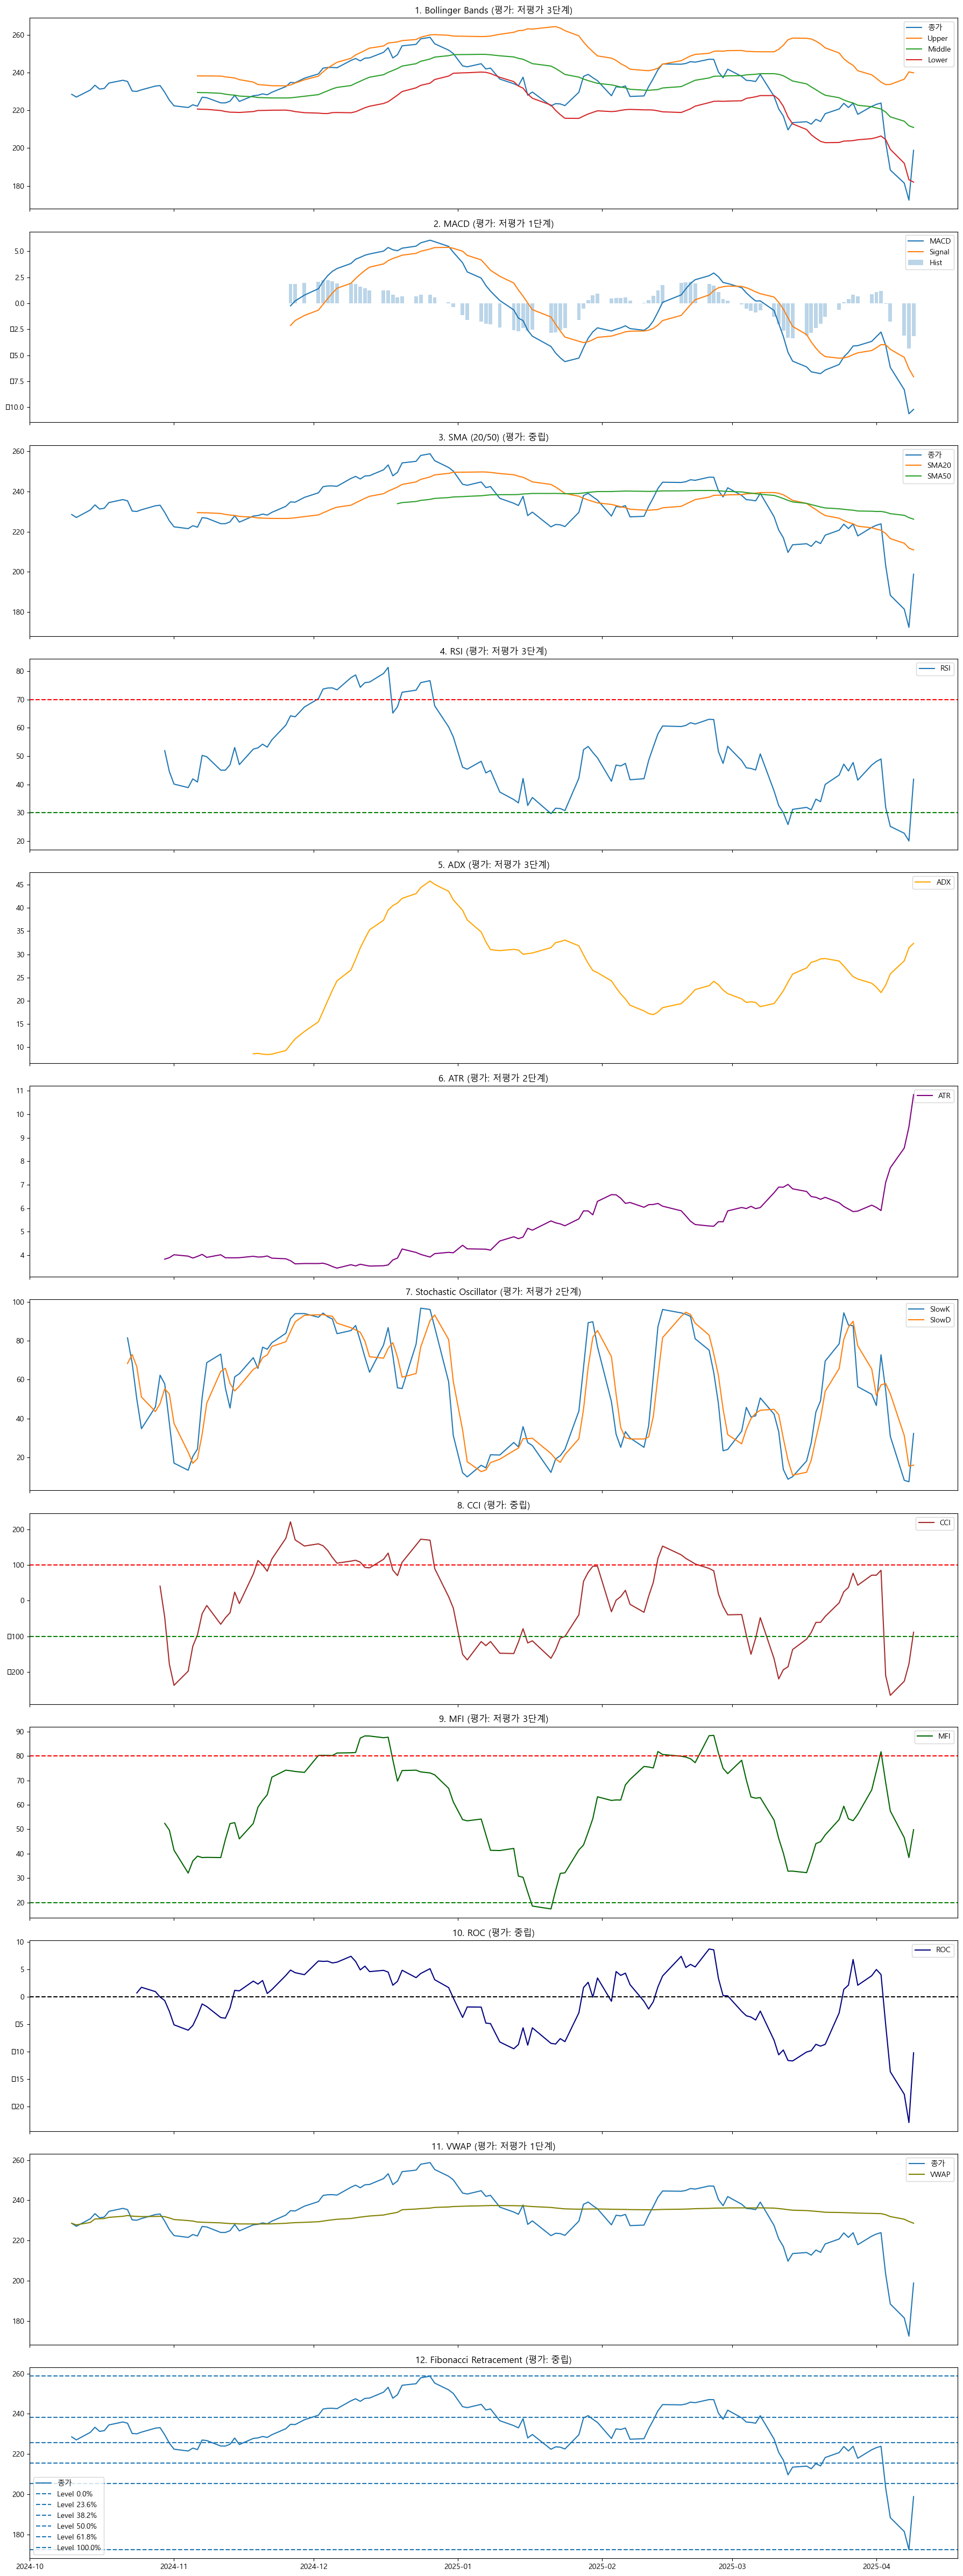

AAPL 분석 결과가 CSV 파일로 저장되었습니다.


In [13]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import yfinance as yf
import talib
import numpy as np
import pandas as pd
import os

# 폰트 설정 (Windows 기준, 맑은 고딕)
font_path = "C:/Windows/Fonts/malgun.ttf"
font_prop = fm.FontProperties(fname=font_path)
plt.rc("font", family=font_prop.get_name())

# 주식 데이터 가져오기
def get_stock_data(ticker="AAPL", period="6mo", interval="1d"):
    try:
        stock = yf.Ticker(ticker)
        df = stock.history(period=period, interval=interval)
        if df.empty:
            raise ValueError(f"{ticker}에 대한 데이터가 없습니다.")
        df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
        df.dropna(inplace=True)
        return df
    except Exception as e:
        print(f"데이터 가져오기 오류: {e}")
        return None

# 지표 평가 함수 (동적 임계값 추가)
def evaluate_indicator(value, thresholds, dynamic_data=None):
    if dynamic_data:
        atr_mean = dynamic_data.get('atr_mean', 1.0)
        # ATR로 임계값 스케일링 (변동성 반영)
        thresholds = {k: v * atr_mean for k, v in thresholds.items()}
    if value >= thresholds['over3']:
        return "고평가 3단계"
    elif value >= thresholds['over2']:
        return "고평가 2단계"
    elif value >= thresholds['over1']:
        return "고평가 1단계"
    elif value <= thresholds['under3']:
        return "저평가 3단계"
    elif value <= thresholds['under2']:
        return "저평가 2단계"
    elif value <= thresholds['under1']:
        return "저평가 1단계"
    else:
        return "중립"

# 평가를 수치로 변환
def eval_to_score(eval_str):
    eval_map = {
        "고평가 3단계": -3, "고평가 2단계": -2, "고평가 1단계": -1,
        "중립": 0,
        "저평가 1단계": 1, "저평가 2단계": 2, "저평가 3단계": 3
    }
    return eval_map.get(eval_str, 0)

# 기술적 지표 계산
def compute_indicators(df):
    try:
        indicators = {}
        close = df['Close']
        high = df['High']
        low = df['Low']
        volume = df['Volume']
        atr = talib.ATR(high, low, close)  # 동적 임계값 계산용 ATR
        dynamic_data = {'atr_mean': atr.mean()}

        # 볼린저 밴드
        upper, middle, lower = talib.BBANDS(close, timeperiod=20)
        indicators['Bollinger'] = {'upper': upper, 'middle': middle, 'lower': lower, 'eval': evaluate_indicator(close.iloc[-1], {
            'over3': upper.iloc[-1]*1.01, 'over2': upper.iloc[-1], 'over1': middle.iloc[-1]*1.05,
            'under3': lower.iloc[-1]*0.99, 'under2': lower.iloc[-1], 'under1': middle.iloc[-1]*0.95
        }, dynamic_data)}

        # MACD
        macd, signal, hist = talib.MACD(close)
        indicators['MACD'] = {'macd': macd, 'signal': signal, 'hist': hist, 'eval': evaluate_indicator(hist.iloc[-1], {
            'over3': 2.0, 'over2': 1.0, 'over1': 0.5, 'under3': -2.0, 'under2': -1.0, 'under1': -0.5
        }, dynamic_data)}

        # SMA
        sma20 = talib.SMA(close, timeperiod=20)
        sma50 = talib.SMA(close, timeperiod=50)
        indicators['SMA'] = {'sma20': sma20, 'sma50': sma50, 'eval': evaluate_indicator(sma20.iloc[-1] - sma50.iloc[-1], {
            'over3': 15, 'over2': 10, 'over1': 5, 'under3': -15, 'under2': -10, 'under1': -5
        }, dynamic_data)}

        # RSI
        rsi = talib.RSI(close)
        indicators['RSI'] = {'rsi': rsi, 'eval': evaluate_indicator(rsi.iloc[-1], {
            'over3': 85, 'over2': 75, 'over1': 70, 'under3': 15, 'under2': 25, 'under1': 30
        }, dynamic_data)}

        # ADX
        adx = talib.ADX(high, low, close)
        indicators['ADX'] = {'adx': adx, 'eval': evaluate_indicator(adx.iloc[-1], {
            'over3': 50, 'over2': 40, 'over1': 30, 'under3': 10, 'under2': 15, 'under1': 20
        }, dynamic_data)}

        # ATR
        indicators['ATR'] = {'atr': atr, 'eval': evaluate_indicator(atr.iloc[-1], {
            'over3': atr.mean() * 2.0, 'over2': atr.mean() * 1.5, 'over1': atr.mean() * 1.2,
            'under3': atr.mean() * 0.3, 'under2': atr.mean() * 0.5, 'under1': atr.mean() * 0.8
        }, dynamic_data)}

        # Stochastic
        slowk, slowd = talib.STOCH(high, low, close)
        indicators['Stochastic'] = {'slowk': slowk, 'slowd': slowd, 'eval': evaluate_indicator(slowk.iloc[-1], {
            'over3': 95, 'over2': 90, 'over1': 80, 'under3': 5, 'under2': 10, 'under1': 20
        }, dynamic_data)}

        # CCI
        cci = talib.CCI(high, low, close)
        indicators['CCI'] = {'cci': cci, 'eval': evaluate_indicator(cci.iloc[-1], {
            'over3': 300, 'over2': 200, 'over1': 100, 'under3': -300, 'under2': -200, 'under1': -100
        }, dynamic_data)}

        # MFI
        mfi = talib.MFI(high, low, close, volume)
        indicators['MFI'] = {'mfi': mfi, 'eval': evaluate_indicator(mfi.iloc[-1], {
            'over3': 90, 'over2': 80, 'over1': 75, 'under3': 10, 'under2': 20, 'under1': 25
        }, dynamic_data)}

        # ROC
        roc = talib.ROC(close)
        indicators['ROC'] = {'roc': roc, 'eval': evaluate_indicator(roc.iloc[-1], {
            'over3': 30, 'over2': 20, 'over1': 10, 'under3': -30, 'under2': -20, 'under1': -10
        }, dynamic_data)}

        # VWAP
        vwap = (close * volume).cumsum() / volume.cumsum()
        indicators['VWAP'] = {'vwap': vwap, 'eval': evaluate_indicator(close.iloc[-1] - vwap.iloc[-1], {
            'over3': 15, 'over2': 10, 'over1': 5, 'under3': -15, 'under2': -10, 'under1': -5
        }, dynamic_data)}

        # 피보나치 되돌림
        max_price = close.max()
        min_price = close.min()
        diff = max_price - min_price
        retracement_levels = {
            '0.0%': max_price, '23.6%': max_price - 0.236 * diff, '38.2%': max_price - 0.382 * diff,
            '50.0%': max_price - 0.5 * diff, '61.8%': max_price - 0.618 * diff, '100.0%': min_price
        }
        current_price = close.iloc[-1]
        indicators['Fibonacci'] = {'levels': retracement_levels, 'eval': evaluate_indicator(current_price - retracement_levels['50.0%'], {
            'over3': diff * 0.4, 'over2': diff * 0.3, 'over1': diff * 0.2,
            'under3': -diff * 0.4, 'under2': -diff * 0.3, 'under1': -diff * 0.2
        }, dynamic_data)}

        return indicators, df
    except Exception as e:
        print(f"지표 계산 오류: {e}")
        return None, df

# 지표 시각화
def plot_indicators(indicators, df, ticker):
    close = df['Close']
    date_index = df.index
    fig, axs = plt.subplots(nrows=12, ncols=1, figsize=(18, 48), sharex=True)

    titles = [
        "1. Bollinger Bands", "2. MACD", "3. SMA (20/50)", "4. RSI", "5. ADX", "6. ATR",
        "7. Stochastic Oscillator", "8. CCI", "9. MFI", "10. ROC", "11. VWAP", "12. Fibonacci Retracement"
    ]

    axs[0].plot(date_index, close, label="종가")
    axs[0].plot(date_index, indicators['Bollinger']['upper'], label="Upper")
    axs[0].plot(date_index, indicators['Bollinger']['middle'], label="Middle")
    axs[0].plot(date_index, indicators['Bollinger']['lower'], label="Lower")
    axs[0].set_title(f"{titles[0]} (평가: {indicators['Bollinger']['eval']})")
    axs[0].legend()

    axs[1].plot(date_index, indicators['MACD']['macd'], label="MACD")
    axs[1].plot(date_index, indicators['MACD']['signal'], label="Signal")
    axs[1].bar(date_index, indicators['MACD']['hist'], alpha=0.3, label="Hist")
    axs[1].set_title(f"{titles[1]} (평가: {indicators['MACD']['eval']})")
    axs[1].legend()

    axs[2].plot(date_index, close, label="종가")
    axs[2].plot(date_index, indicators['SMA']['sma20'], label="SMA20")
    axs[2].plot(date_index, indicators['SMA']['sma50'], label="SMA50")
    axs[2].set_title(f"{titles[2]} (평가: {indicators['SMA']['eval']})")
    axs[2].legend()

    axs[3].plot(date_index, indicators['RSI']['rsi'], label="RSI")
    axs[3].axhline(70, linestyle="--", color="red")
    axs[3].axhline(30, linestyle="--", color="green")
    axs[3].set_title(f"{titles[3]} (평가: {indicators['RSI']['eval']})")
    axs[3].legend()

    axs[4].plot(date_index, indicators['ADX']['adx'], label="ADX", color="orange")
    axs[4].set_title(f"{titles[4]} (평가: {indicators['ADX']['eval']})")
    axs[4].legend()

    axs[5].plot(date_index, indicators['ATR']['atr'], label="ATR", color="purple")
    axs[5].set_title(f"{titles[5]} (평가: {indicators['ATR']['eval']})")
    axs[5].legend()

    axs[6].plot(date_index, indicators['Stochastic']['slowk'], label="SlowK")
    axs[6].plot(date_index, indicators['Stochastic']['slowd'], label="SlowD")
    axs[6].set_title(f"{titles[6]} (평가: {indicators['Stochastic']['eval']})")
    axs[6].legend()

    axs[7].plot(date_index, indicators['CCI']['cci'], label="CCI", color="brown")
    axs[7].axhline(100, linestyle="--", color="red")
    axs[7].axhline(-100, linestyle="--", color="green")
    axs[7].set_title(f"{titles[7]} (평가: {indicators['CCI']['eval']})")
    axs[7].legend()

    axs[8].plot(date_index, indicators['MFI']['mfi'], label="MFI", color="darkgreen")
    axs[8].axhline(80, linestyle="--", color="red")
    axs[8].axhline(20, linestyle="--", color="green")
    axs[8].set_title(f"{titles[8]} (평가: {indicators['MFI']['eval']})")
    axs[8].legend()

    axs[9].plot(date_index, indicators['ROC']['roc'], label="ROC", color="navy")
    axs[9].axhline(0, linestyle="--", color="black")
    axs[9].set_title(f"{titles[9]} (평가: {indicators['ROC']['eval']})")
    axs[9].legend()

    axs[10].plot(date_index, close, label="종가")
    axs[10].plot(date_index, indicators['VWAP']['vwap'], label="VWAP", color="olive")
    axs[10].set_title(f"{titles[10]} (평가: {indicators['VWAP']['eval']})")
    axs[10].legend()

    axs[11].plot(date_index, close, label="종가")
    for level, val in indicators['Fibonacci']['levels'].items():
        axs[11].axhline(val, linestyle="--", label=f"Level {level}")
    axs[11].set_title(f"{titles[11]} (평가: {indicators['Fibonacci']['eval']})")
    axs[11].legend()

    plt.tight_layout()
    plt.savefig(f"{ticker}_indicators.png")
    plt.show()

# 종합 평가 계산 (신뢰도 추가)
def compute_composite_score(indicators, df):
    weights = {
        'Bollinger': 1.0, 'MACD': 1.5, 'SMA': 1.0, 'RSI': 1.5, 'ADX': 0.8,
        'ATR': 0.5, 'Stochastic': 1.2, 'CCI': 1.0, 'MFI': 1.0, 'ROC': 0.8,
        'VWAP': 1.0, 'Fibonacci': 0.8
    }
    # ADX로 추세 강도 기반 신뢰도 계산
    adx_value = indicators['ADX']['adx'].iloc[-1]
    reliability = {
        'ADX': min(1.0, adx_value / 25),  # 추세 강할수록 ADX 신뢰도 증가
        'RSI': max(0.5, 1.0 - adx_value / 50),  # 추세 약할수록 RSI 신뢰도 증가
        'MACD': min(1.0, adx_value / 30),  # 추세 강할수록 MACD 신뢰도 증가
        'Stochastic': max(0.5, 1.0 - adx_value / 50),  # 횡보장일수록 신뢰도 증가
    }
    reliability = {k: reliability.get(k, 1.0) for k in weights.keys()}

    total_score = 0
    total_weight = 0
    over_count = 0
    under_count = 0

    for name, data in indicators.items():
        score = eval_to_score(data['eval'])
        weight = weights.get(name, 1.0) * reliability[name]
        total_score += score * weight
        total_weight += weight
        if score < 0:
            over_count += 1
        elif score > 0:
            under_count += 1

    composite_score = total_score / total_weight if total_weight > 0 else 0

    # 다수결 판단
    if under_count > over_count + 2:
        majority_signal = "저평가 경향"
    elif over_count > under_count + 2:
        majority_signal = "고평가 경향"
    else:
        majority_signal = "중립"

    # 종합 신호
    if composite_score >= 2.0:
        composite_signal = "강한 매수 신호"
    elif composite_score >= 1.0:
        composite_signal = "매수 신호"
    elif composite_score <= -2.0:
        composite_signal = "강한 매도 신호"
    elif composite_score <= -1.0:
        composite_signal = "매도 신호"
    else:
        composite_signal = "중립"

    return {
        'composite_score': round(composite_score, 2),
        'majority_signal': majority_signal,
        'composite_signal': composite_signal
    }

# 요약 출력
def print_summary(indicators, composite_result, ticker):
    print(f"\n{ticker} 기술적 지표 분석 결과:")
    for name, data in indicators.items():
        print(f"{name}: {data['eval']} (점수: {eval_to_score(data['eval'])})")
    print("\n종합 평가:")
    print(f"종합 점수: {composite_result['composite_score']}")
    print(f"다수결 신호: {composite_result['majority_signal']}")
    print(f"종합 신호: {composite_result['composite_signal']}")

# CSV로 저장
def save_to_csv(indicators, composite_result, ticker):
    eval_data = {name: data['eval'] for name, data in indicators.items()}
    eval_data.update(composite_result)
    df_eval = pd.DataFrame([eval_data])
    df_eval.to_csv(f"{ticker}_indicators_eval.csv", index=False, encoding='utf-8-sig')
    print(f"{ticker} 분석 결과가 CSV 파일로 저장되었습니다.")

# 메인 실행 함수
def main():
    ticker = input("분석할 주식 티커를 입력하세요 (기본값: AAPL): ") or "AAPL"
    period = input("데이터 기간을 입력하세요 (예: 6mo, 1y, 기본값: 6mo): ") or "6mo"
    interval = input("데이터 간격을 입력하세요 (예: 1d, 1h, 기본값: 1d): ") or "1d"

    df = get_stock_data(ticker, period, interval)
    if df is None:
        return

    indicators, df = compute_indicators(df)
    if indicators is None:
        return

    composite_result = compute_composite_score(indicators, df)
    print_summary(indicators, composite_result, ticker)
    plot_indicators(indicators, df, ticker)
    save_to_csv(indicators, composite_result, ticker)

if __name__ == "__main__":
    main()